In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/ST7242J0-PSG_spectral.pt
/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/ST7052J0-PSG_spectral.pt
/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/SC4492G0-PSG_spectral.pt
/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/SC4821G0-PSG_spectral.pt
/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/SC4742E0-PSG_spectral.pt
/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/SC4472F0-PSG_spectral.pt
/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/SC4822G0-PSG_spectral.pt
/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/ST7241J0-PSG_spectral.pt
/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/SC4061E0-PSG_spectral.pt
/kaggle/input/datasets/girishgiriirig

In [2]:
import pandas as pd
import os

# Read the CSV file (replace 'input.csv' with your actual filename)
df = pd.read_csv('/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/processed_sleepedf/index.csv')

# Add tensor_path column: basepath + new prefix + _spectral.pt
def create_spectral_path(filename):
    base_name = filename.split('\\')[-1][:-3]  # Get filename without extension
    new_path = f"/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral/{base_name}_spectral.pt"
    return new_path

def create_raw_path(filename):
    base_name = filename.split('\\')[-1][:-3]  # Get filename without extension
    new_path = f'/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/processed_sleepedf/tensors/{base_name}.pt'
    return new_path

# Assuming there's a column with original paths/filenames (adjust column name as needed)
df['spectral'] = df['tensor_path'].apply(create_spectral_path)  # Replace 'path_column' with actual column
df['tensor_path'] = df['tensor_path'].apply(create_raw_path)
# Create/modify spectral column (example - adjust logic as needed)
# df['spectral'] = df['tensor_path']  # Or whatever transformation you need

# Save modified CSV
df.to_csv('output.csv', index=False)
print("Modified CSV saved as 'output.csv'")
print(df[['tensor_path', 'spectral']].head())


Modified CSV saved as 'output.csv'
                                         tensor_path  \
0  /kaggle/input/datasets/girishgiriirig/sleep-ed...   
1  /kaggle/input/datasets/girishgiriirig/sleep-ed...   
2  /kaggle/input/datasets/girishgiriirig/sleep-ed...   
3  /kaggle/input/datasets/girishgiriirig/sleep-ed...   
4  /kaggle/input/datasets/girishgiriirig/sleep-ed...   

                                            spectral  
0  /kaggle/input/datasets/girishgiriirig/sleep-ed...  
1  /kaggle/input/datasets/girishgiriirig/sleep-ed...  
2  /kaggle/input/datasets/girishgiriirig/sleep-ed...  
3  /kaggle/input/datasets/girishgiriirig/sleep-ed...  
4  /kaggle/input/datasets/girishgiriirig/sleep-ed...  


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader, Subset, random_split
import torch.nn as nn
import torch.nn.functional as F
import math
import random
import time
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    cohen_kappa_score, confusion_matrix
)
import json
from sklearn.model_selection import train_test_split

# Ablation: Temporal-Only Sleep Staging

This notebook removes the spectral branch entirely. The model uses only the CNN temporal encoder → Transformer pipeline. No spectral features are loaded or processed.

In [4]:
STAGE_TO_IDX = {
    "W": 0,
    "N1": 1,
    "N2": 2,
    "N3": 3,
    "REM": 4
}

IDX_TO_STAGE = {v: k for k, v in STAGE_TO_IDX.items()}
NUM_CLASSES = 5


class TemporalOnlySleepDataset(Dataset):
    """
    Ablation dataset — loads ONLY temporal (raw EEG) tensors.
    Spectral features are dropped entirely.

        x_temporal : [W, 3000]
        y          : [W]
    """

    def __init__(self, csv_path, file_indices=None, window_size=256, overlap=0):
        assert overlap < window_size, "overlap must be < window_size"

        self.df = pd.read_csv(csv_path)
        if file_indices is not None:
            self.df = self.df.iloc[file_indices].reset_index(drop=True)

        self.window_size = window_size
        self.stride      = window_size - overlap

        self.index = []
        for row_idx, row in self.df.iterrows():
            T = len(row['stage_sequence'].split(' '))
            start = 0
            while start < T:
                self.index.append((row_idx, start))
                start += self.stride

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        row_idx, start = self.index[idx]
        row = self.df.iloc[row_idx]
        end = start + self.window_size

        x_temporal = torch.load(row['tensor_path']).float()[start:end]  # [W, 3000]

        stages = row['stage_sequence'].split(' ')[start:end]
        y = torch.tensor([STAGE_TO_IDX[s] for s in stages], dtype=torch.long)

        return x_temporal, y


In [5]:
def temporal_collate_fn(batch):
    """
    Collates a batch of (x_temporal, y) tuples.
    Returns:
        x_temp       : [B, T_max, 3000]
        y_padded     : [B, T_max]        — padded with -100
        padding_mask : [B, T_max] bool   — True where padded
    """
    lengths  = [xt.shape[0] for xt, _ in batch]
    max_len  = max(lengths)
    B        = len(batch)
    temp_dim = batch[0][0].shape[1]   # 3000

    x_temp   = torch.zeros(B, max_len, temp_dim)
    y_padded = torch.full((B, max_len), -100, dtype=torch.long)
    pad_mask = torch.ones(B, max_len, dtype=torch.bool)

    for i, (xt, y) in enumerate(batch):
        T = xt.shape[0]
        x_temp[i,   :T] = xt
        y_padded[i, :T] = y
        pad_mask[i, :T] = False

    return x_temp, y_padded, pad_mask


In [6]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        s = x.mean(dim=-1)
        s = F.relu(self.fc1(s))
        s = torch.sigmoid(self.fc2(s))
        return x * s.unsqueeze(-1)


class AdaptiveAtrousPyramid(nn.Module):
    def __init__(self, in_channels=1, hidden_channels=64, dilations=(1, 2, 4, 8)):
        super().__init__()
        self.branches = nn.ModuleList([
            nn.Conv1d(in_channels, hidden_channels, kernel_size=7,
                      dilation=d, padding=3 * d) for d in dilations
        ])
        self.gate = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(hidden_channels * len(dilations), len(dilations), 1),
            nn.Softmax(dim=1)
        )
        self.se   = SEBlock(hidden_channels)
        self.proj = nn.Conv1d(hidden_channels, hidden_channels, 1)

    def forward(self, x):
        feats   = [F.relu(b(x)) for b in self.branches]
        stacked = torch.cat(feats, dim=1)
        weights = self.gate(stacked)
        out = 0
        for i, f in enumerate(feats):
            out = out + f * weights[:, i:i+1]
        return self.proj(self.se(out))


class EpochEncoder(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.pyramid = AdaptiveAtrousPyramid()
        self.pool    = nn.AdaptiveAvgPool1d(1)
        self.fc      = nn.Linear(64, embed_dim)

    def forward(self, x):
        B, T, L = x.shape
        x = x.view(B * T, 1, L)
        f = self.pyramid(x)
        f = self.pool(f).squeeze(-1)
        f = self.fc(f)
        return f.view(B, T, -1)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class SleepTransformer(nn.Module):
    def __init__(self, embed_dim=128, heads=4, layers=4, dropout=0.2, max_len=512):
        super().__init__()
        self.positional_encoding = PositionalEncoding(embed_dim, max_len)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=heads,
            dim_feedforward=embed_dim * 4, dropout=dropout,
            batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, layers)
        self.cls     = nn.Linear(embed_dim, NUM_CLASSES)

    def forward(self, x, padding_mask=None):
        x = self.positional_encoding(x)
        h = self.encoder(x, src_key_padding_mask=padding_mask)
        return self.cls(h)


# ── Ablation: Temporal-Only model ────────────────────────────────────────────
class TemporalOnlySleepStagingModel(nn.Module):
    """
    Ablation model — no spectral branch, no fusion.
    Pipeline: EpochEncoder (CNN pyramid) → SleepTransformer → classification.
    Returns (logits, aux_logits) where aux_logits mirrors the main head
    (same tensor) so the training loop stays compatible.
    """
    def __init__(self, embed_dim=128, heads=4, layers=6, dropout=0.2):
        super().__init__()
        self.temporal_encoder = EpochEncoder(embed_dim=embed_dim)
        self.context          = SleepTransformer(
            embed_dim=embed_dim, heads=heads,
            layers=layers, dropout=dropout
        )

    def forward(self, x_temp, padding_mask=None):
        feats  = self.temporal_encoder(x_temp)
        logits = self.context(feats, padding_mask)
        # Return (main_logits, aux_logits) — aux mirrors main for loss compat
        return logits, logits


In [7]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, num_classes=5):
        super().__init__()
        self.gamma = gamma
        if alpha is None:
            self.register_buffer('alpha', torch.ones(num_classes))
        else:
            self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float))

    def forward(self, logits, targets):
        valid   = targets != -100
        logits  = logits[valid]
        targets = targets[valid]
        if logits.numel() == 0:
            return logits.sum() * 0.0
        ce   = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt   = torch.exp(-ce)
        loss = (1 - pt) ** self.gamma * ce
        return loss.mean()


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def compute_specificity(y_true, y_pred, num_classes=5):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specs = []
    for i in range(num_classes):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specs.append(tn / (tn + fp + 1e-8))
    return float(np.mean(specs))


def compute_metrics(y_true, y_pred, y_prob):
    metrics = {
        "accuracy":     accuracy_score(y_true, y_pred),
        "f1_weighted":  f1_score(y_true, y_pred, average="weighted"),
        "f1_macro":     f1_score(y_true, y_pred, average="macro"),
        "precision":    precision_score(y_true, y_pred, average="weighted"),
        "recall":       recall_score(y_true, y_pred, average="weighted"),
        "kappa":        cohen_kappa_score(y_true, y_pred),
        "specificity":  compute_specificity(y_true, y_pred)
    }
    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob, multi_class="ovr", average="weighted")
        metrics["pr_auc"]  = average_precision_score(y_true, y_prob, average="weighted")
    except ValueError:
        metrics["roc_auc"] = None
        metrics["pr_auc"]  = None
    return metrics


def logger(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}")


In [8]:
def evaluate_temporal(model, loader, device):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    use_amp = device.type == 'cuda'

    with torch.no_grad():
        for x_temp, y, padding_mask in loader:
            x_temp       = x_temp.to(device)
            y            = y.to(device)
            padding_mask = padding_mask.to(device)

            with torch.amp.autocast(device_type='cuda', enabled=use_amp):
                logits, _ = model(x_temp, padding_mask)

            probs = torch.softmax(logits, dim=-1)
            preds = probs.argmax(dim=-1)
            valid = ~padding_mask

            y_true.extend(y[valid].cpu().numpy())
            y_pred.extend(preds[valid].cpu().numpy())
            y_prob.extend(probs[valid].cpu().numpy())

    return compute_metrics(np.array(y_true), np.array(y_pred), np.array(y_prob))


def train_model_temporal(train_dataset, val_dataset, device, epochs=150):

    train_loader = DataLoader(
        train_dataset, batch_size=16, shuffle=True,
        num_workers=2, collate_fn=temporal_collate_fn,
        pin_memory=True, persistent_workers=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=16, shuffle=False,
        num_workers=2, collate_fn=temporal_collate_fn,
        pin_memory=True, persistent_workers=True
    )

    model = nn.DataParallel(TemporalOnlySleepStagingModel()).to(device)

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    logger(f"Temporal-Only model on {device}")
    logger(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")
    logger(f"Train chunks: {len(train_dataset):,} | Val chunks: {len(val_dataset):,}")

    class_counts  = torch.tensor([70154, 25175, 88983, 19454, 34184], dtype=torch.float)
    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.sum() * NUM_CLASSES
    criterion = FocalLoss(alpha=class_weights, gamma=2.0).to(device)
    AUX_WEIGHT = 0.3   # auxiliary head weight (mirrors main logits here)

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=3e-4,
        steps_per_epoch=len(train_loader),
        epochs=epochs, pct_start=0.05
    )
    scaler  = torch.amp.GradScaler()
    best_f1 = -1

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch_idx, (x_temp, y, padding_mask) in enumerate(train_loader):
            x_temp       = x_temp.to(device)
            y            = y.to(device)
            padding_mask = padding_mask.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast(device_type='cuda'):
                logits, aux_logits = model(x_temp, padding_mask)
                y_flat    = y.view(-1)
                loss_main = criterion(logits.view(-1, NUM_CLASSES), y_flat)
                loss_aux  = criterion(aux_logits.view(-1, NUM_CLASSES), y_flat)
                loss      = loss_main + AUX_WEIGHT * loss_aux

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            if device.type == 'cuda' and batch_idx % 50 == 0:
                mem_alloc    = torch.cuda.memory_allocated() / 1024**2
                mem_reserved = torch.cuda.memory_reserved() / 1024**2
                print(f"  GPU | Alloc: {mem_alloc:.1f} MB | Reserved: {mem_reserved:.1f} MB")

            total_loss += loss.item()

        metrics = evaluate_temporal(model, val_loader, device)

        log = {'epoch': epoch, 'train_loss': total_loss / len(train_loader), **metrics}
        with open('/kaggle/working/training_metrics_temporal_only.jsonl', 'a') as f:
            f.write(json.dumps(log) + '\n')

        if metrics['f1_weighted'] > best_f1:
            best_f1 = metrics['f1_weighted']
            torch.save(model.state_dict(), '/kaggle/working/best_model_temporal_only.pt')

        logger(
            f"Epoch {epoch:3d} | Loss: {total_loss/len(train_loader):.4f} | "
            f"F1: {metrics['f1_weighted']:.4f} | Acc: {metrics['accuracy']:.4f} | "
            f"Kappa: {metrics['kappa']:.4f}"
        )

    logger(f"Training complete — best val F1: {best_f1:.4f}")
    logger("Saved → /kaggle/working/best_model_temporal_only.pt")
    return model


In [9]:
def main():
    set_seed(42)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    csv_path = '/kaggle/working/output.csv'

    tmp = pd.read_csv(csv_path)
    num_files = len(tmp)
    print(f"Total files: {num_files}")

    indices = list(range(num_files))
    train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

    WINDOW_SIZE = 256
    OVERLAP     = 0

    train_dataset = TemporalOnlySleepDataset(csv_path, file_indices=train_idx,
                                             window_size=WINDOW_SIZE, overlap=OVERLAP)
    val_dataset   = TemporalOnlySleepDataset(csv_path, file_indices=val_idx,
                                             window_size=WINDOW_SIZE, overlap=OVERLAP)

    print(f"Train files: {len(train_idx)} → {len(train_dataset):,} chunks")
    print(f"Val   files: {len(val_idx)}  → {len(val_dataset):,} chunks")

    train_model_temporal(train_dataset, val_dataset, device, epochs=150)

main()


Total files: 197
Train files: 157 → 813 chunks
Val   files: 40  → 210 chunks


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[06:02:44] Temporal-Only model on cuda
[06:02:44] Total params: 1,206,413 | Trainable: 1,206,413
[06:02:44] Train chunks: 813 | Val chunks: 210


/tmp/ipykernel_55/1102840021.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float))


  GPU | Alloc: 73.9 MB | Reserved: 12090.0 MB
  GPU | Alloc: 74.0 MB | Reserved: 13624.0 MB
[06:03:37] Epoch   0 | Loss: 1.0213 | F1: 0.1205 | Acc: 0.1315 | Kappa: -0.0016
  GPU | Alloc: 82.1 MB | Reserved: 13624.0 MB
  GPU | Alloc: 74.0 MB | Reserved: 13624.0 MB


...

[06:50:08] Epoch  61 | Loss: 0.7786 | F1: 0.0975 | Acc: 0.1365 | Kappa: 0.0306
  GPU | Alloc: 82.1 MB | Reserved: 13624.0 MB
  GPU | Alloc: 74.0 MB | Reserved: 13624.0 MB


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[06:50:54] Epoch  62 | Loss: 0.7783 | F1: 0.0992 | Acc: 0.1375 | Kappa: 0.0289
  GPU | Alloc: 82.1 MB | Reserved: 13624.0 MB
  GPU | Alloc: 74.0 MB | Reserved: 13624.0 MB


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[06:51:40] Epoch  63 | Loss: 0.7780 | F1: 0.1015 | Acc: 0.1344 | Kappa: 0.0322
  GPU | Alloc: 82.1 MB | Reserved: 13624.0 MB
  GPU | Alloc: 74.0 MB | Reserved: 13624.0 MB
[06:52:26] Epoch  64 | Loss: 0.7762 | F1: 0.1047 | Acc: 0.1366 | Kappa: 0.0339
  GPU | Alloc: 82.1 MB | Reserved: 13624.0 MB
  GPU | Alloc: 74.0 MB | Reserved: 13624.0 MB
[06:53:12] Epoch  65 | Loss: 0.7756 | F1: 0.1061 | Acc: 0.1380 | Kappa: 0.0329
  GPU | Alloc: 82.1 MB | Reserved: 13624.0 MB
  GPU | Alloc: 74.0 MB | Reserved: 13624.0 MB
[06:53:57] Epoch  66 | Loss: 0.7765 | F1: 0.0937 | Acc: 0.1285 | Kappa: 0.0290
  GPU | Alloc: 82.1 MB | Reserved: 13624.0 MB
  GPU | Alloc: 74.0 MB | Reserved: 13624.0 MB
[06:54:43] Epoch  67 | Loss: 0.7767 | F1: 0.1015 | Acc: 0.1368 | Kappa: 0.0312
  GPU | Alloc: 82.1 MB | Reserved: 13624.0 MB
  GPU | Alloc: 74.0 MB | Reserved: 13624.0 MB
[06:55:29] Epoch  68 | Loss: 0.7763 | F1: 0.1022 | Acc: 0.1362 | Kappa: 0.0315
  GPU | Alloc: 82.1 MB | Reserved: 13624.0 MB
  GPU | Alloc: 74.0 

Full dataset: 1,023 chunks from 197 files
Temporal-only model loaded!



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



=== Classification Report (Temporal-Only Ablation) ===
              precision    recall  f1-score   support

        Wake       0.43      0.33      0.37     70154
          N1       0.14      0.21      0.17     25175
          N2       0.00      0.00      0.00     88983
          N3       0.11      0.55      0.18     19454
         REM       0.17      0.25      0.21     34184

    accuracy                           0.20    237950
   macro avg       0.17      0.27      0.19    237950
weighted avg       0.18      0.20      0.17    237950



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


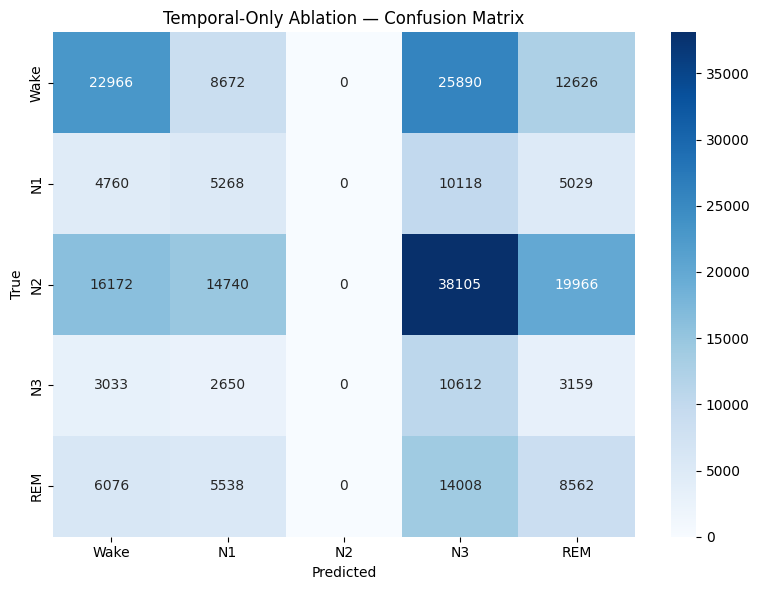

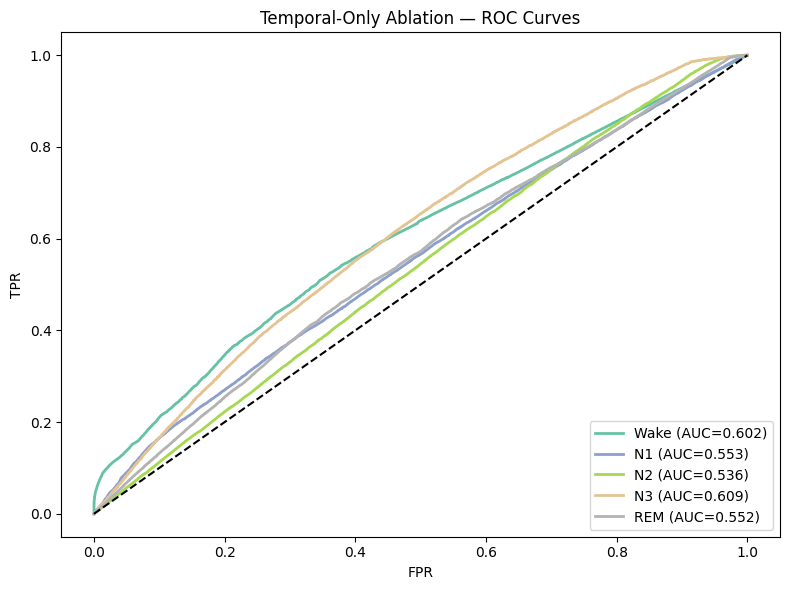

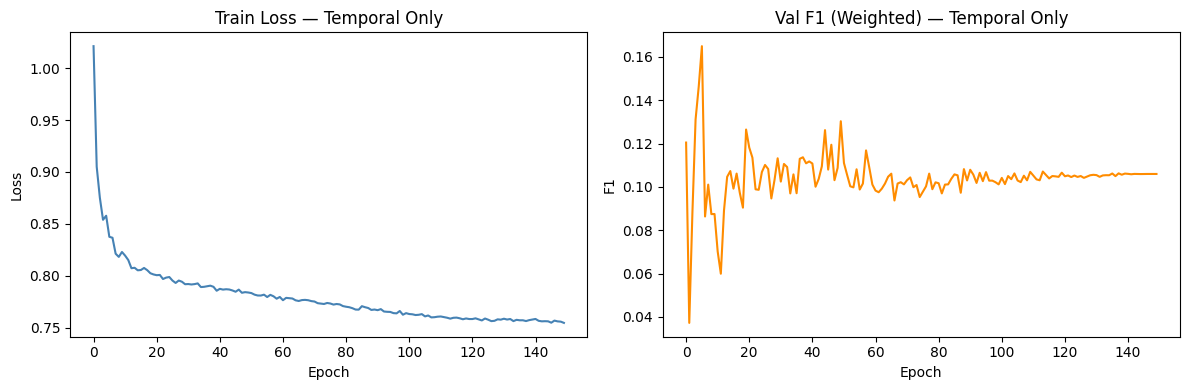


All evaluation artefacts saved to: /kaggle/working/evaluation_results_temporal_only


In [12]:
# ── Post-training evaluation ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
from pathlib import Path

CLASS_NAMES = ['Wake', 'N1', 'N2', 'N3', 'REM']
COLORS      = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))
OUTPUT_DIR  = Path('/kaggle/working/evaluation_results_temporal_only')
OUTPUT_DIR.mkdir(exist_ok=True)

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
csv_path = '/kaggle/working/output.csv'

# ── Smaller batch size + cache clear before loading ──────────────────────────
torch.cuda.empty_cache()

test_dataset = TemporalOnlySleepDataset(csv_path, window_size=256, overlap=0)
test_loader  = DataLoader(
    test_dataset,
    batch_size=4,          # reduced from 16 — CNN pyramid is memory-hungry at eval
    shuffle=False,
    num_workers=2,
    collate_fn=temporal_collate_fn,
    pin_memory=True,
    persistent_workers=True
)
print(f"Full dataset: {len(test_dataset):,} chunks from {len(test_dataset.df)} files")

model = nn.DataParallel(TemporalOnlySleepStagingModel()).to(device)
model.load_state_dict(torch.load('/kaggle/working/best_model_temporal_only.pt', map_location=device))
model.eval()
print("Temporal-only model loaded!\n")

# ── Collect predictions (AMP enabled to halve activation memory) ─────────────
y_true_all, y_pred_all, y_prob_all = [], [], []

with torch.no_grad():
    for x_temp, y, padding_mask in test_loader:
        x_temp       = x_temp.to(device)
        y            = y.to(device)
        padding_mask = padding_mask.to(device)

        with torch.amp.autocast(device_type='cuda'):   # FP16 halves CNN activation size
            logits, _ = model(x_temp, padding_mask)

        probs = torch.softmax(logits.float(), dim=-1)  # cast back to fp32 for softmax
        preds = probs.argmax(dim=-1)
        valid = ~padding_mask

        y_true_all.extend(y[valid].cpu().numpy())
        y_pred_all.extend(preds[valid].cpu().numpy())
        y_prob_all.extend(probs[valid].cpu().numpy())

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
y_prob_all = np.array(y_prob_all)

# ── Classification report ────────────────────────────────────────────────────
print("\n=== Classification Report (Temporal-Only Ablation) ===")
print(classification_report(y_true_all, y_pred_all, target_names=CLASS_NAMES))

# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_true_all, y_pred_all)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Temporal-Only Ablation — Confusion Matrix')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_temporal_only.png', dpi=150)
plt.show()

# ── ROC curves ───────────────────────────────────────────────────────────────
y_bin = label_binarize(y_true_all, classes=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(8, 6))
for i, (name, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob_all[:, i])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={roc_auc_val:.3f})")
ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Temporal-Only Ablation — ROC Curves')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves_temporal_only.png', dpi=150)
plt.show()

# ── Training curve ───────────────────────────────────────────────────────────
import json as _json
logs = [_json.loads(l) for l in open('/kaggle/working/training_metrics_temporal_only.jsonl')]
epochs_x  = [d['epoch'] for d in logs]
f1_vals   = [d['f1_weighted'] for d in logs]
loss_vals = [d['train_loss'] for d in logs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs_x, loss_vals, color='steelblue')
ax1.set_title('Train Loss — Temporal Only'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax2.plot(epochs_x, f1_vals, color='darkorange')
ax2.set_title('Val F1 (Weighted) — Temporal Only'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves_temporal_only.png', dpi=150)
plt.show()

print(f"\nAll evaluation artefacts saved to: {OUTPUT_DIR}")

Test set: 40 files → 210 chunks
Best temporal-only model loaded!



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



=== Classification Report — Temporal-Only (held-out test set) ===
              precision    recall  f1-score   support

        Wake       0.43      0.32      0.37     14953
          N1       0.12      0.20      0.15      4758
          N2       0.00      0.00      0.00     18444
          N3       0.10      0.50      0.16      3888
         REM       0.14      0.21      0.17      6840

    accuracy                           0.19     48883
   macro avg       0.16      0.25      0.17     48883
weighted avg       0.17      0.19      0.16     48883



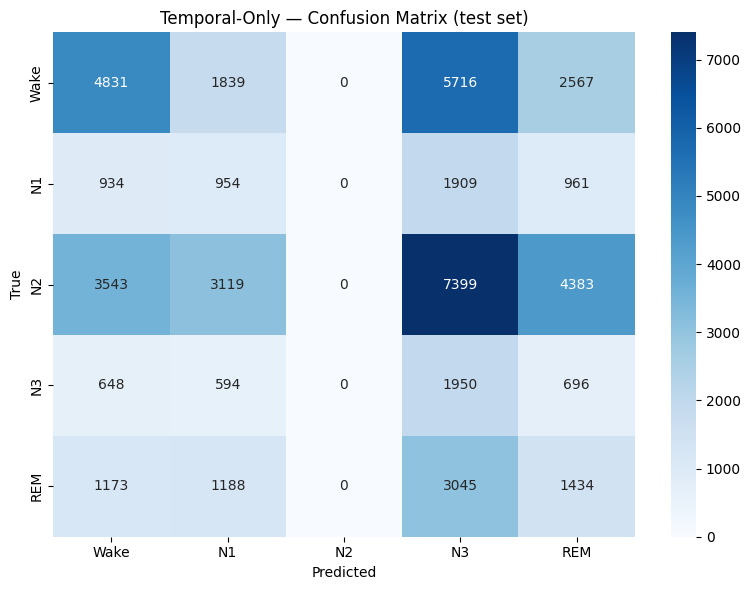

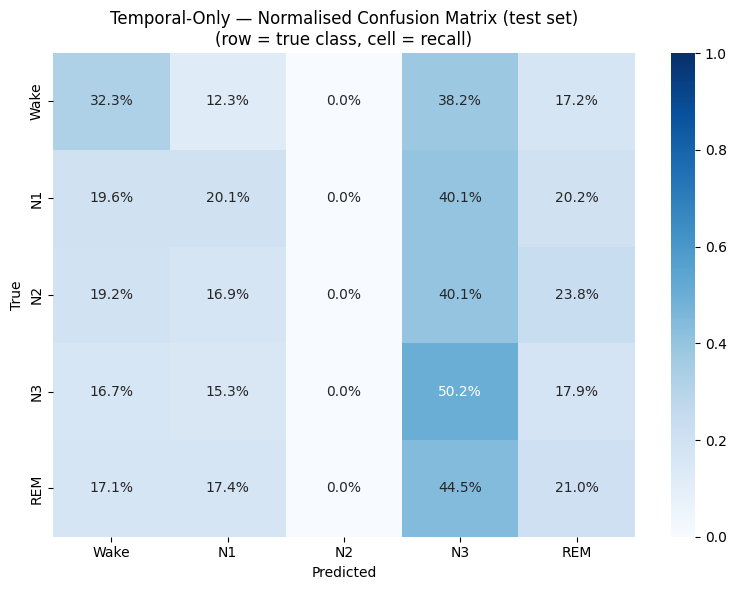

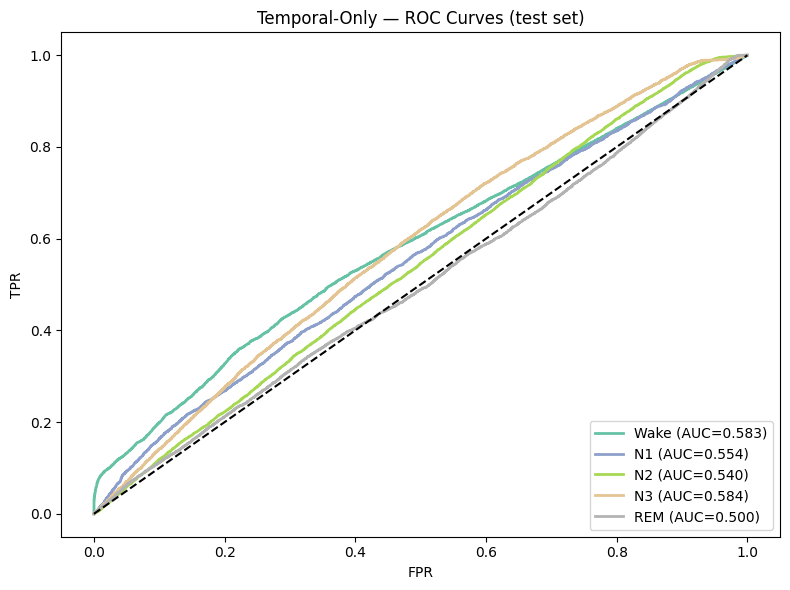

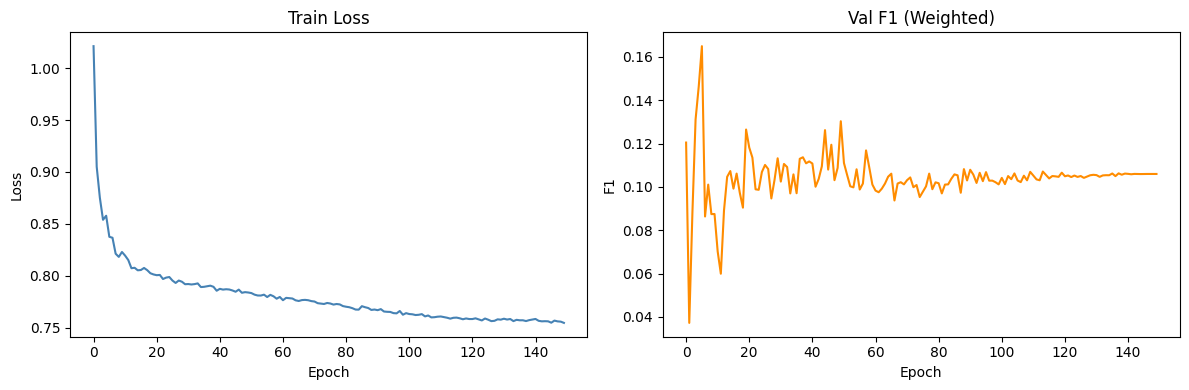


All artefacts saved to: /kaggle/working/evaluation_results_temporal_only


In [15]:
# ── Test-set-only evaluation ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from pathlib import Path

CLASS_NAMES = ['Wake', 'N1', 'N2', 'N3', 'REM']
COLORS      = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))
OUTPUT_DIR  = Path('/kaggle/working/evaluation_results_temporal_only')
OUTPUT_DIR.mkdir(exist_ok=True)

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
csv_path = '/kaggle/working/output.csv'

torch.cuda.empty_cache()

# ── Recreate the exact same held-out split used during training ───────────────
tmp       = pd.read_csv(csv_path)
indices   = list(range(len(tmp)))
_, val_idx = train_test_split(indices, test_size=0.2, random_state=42)  # same seed

test_dataset = TemporalOnlySleepDataset(
    csv_path,
    file_indices=val_idx,   # only the 40 held-out files
    window_size=256,
    overlap=0
)
test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    collate_fn=temporal_collate_fn,
    pin_memory=True,
    persistent_workers=True
)
print(f"Test set: {len(val_idx)} files → {len(test_dataset):,} chunks")

# ── Load best checkpoint ──────────────────────────────────────────────────────
model = nn.DataParallel(TemporalOnlySleepStagingModel()).to(device)
model.load_state_dict(torch.load('/kaggle/working/best_model_temporal_only.pt', map_location=device))
model.eval()
print("Best temporal-only model loaded!\n")

# ── Inference ─────────────────────────────────────────────────────────────────
y_true_all, y_pred_all, y_prob_all = [], [], []

with torch.no_grad():
    for x_temp, y, padding_mask in test_loader:
        x_temp       = x_temp.to(device)
        y            = y.to(device)
        padding_mask = padding_mask.to(device)

        with torch.amp.autocast(device_type='cuda'):
            logits, _ = model(x_temp, padding_mask)

        probs = torch.softmax(logits.float(), dim=-1)
        preds = probs.argmax(dim=-1)
        valid = ~padding_mask

        y_true_all.extend(y[valid].cpu().numpy())
        y_pred_all.extend(preds[valid].cpu().numpy())
        y_prob_all.extend(probs[valid].cpu().numpy())

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
y_prob_all = np.array(y_prob_all)

# ── Classification report ─────────────────────────────────────────────────────
print("\n=== Classification Report — Temporal-Only (held-out test set) ===")
print(classification_report(y_true_all, y_pred_all, target_names=CLASS_NAMES,
                             zero_division=0))

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true_all, y_pred_all)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Temporal-Only — Confusion Matrix (test set)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_temporal_only_test.png', dpi=150)
plt.show()

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            vmin=0.0, vmax=1.0, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Temporal-Only — Normalised Confusion Matrix (test set)\n(row = true class, cell = recall)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_temporal_only_test_normalised.png', dpi=150)
plt.show()
# ── ROC curves ────────────────────────────────────────────────────────────────
y_bin = label_binarize(y_true_all, classes=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(8, 6))
for i, (name, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob_all[:, i])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={roc_auc_val:.3f})")
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Temporal-Only — ROC Curves (test set)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves_temporal_only_test.png', dpi=150)
plt.show()

# ── Training curve (for reference) ───────────────────────────────────────────
import json as _json
logs      = [_json.loads(l) for l in open('/kaggle/working/training_metrics_temporal_only.jsonl')]
epochs_x  = [d['epoch'] for d in logs]
f1_vals   = [d['f1_weighted'] for d in logs]
loss_vals = [d['train_loss'] for d in logs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs_x, loss_vals, color='steelblue')
ax1.set_title('Train Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax2.plot(epochs_x, f1_vals, color='darkorange')
ax2.set_title('Val F1 (Weighted)'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves_temporal_only.png', dpi=150)
plt.show()

print(f"\nAll artefacts saved to: {OUTPUT_DIR}")

In [17]:
!pip install thop

In [21]:
!pip install fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=a512826d1ae8e795226dd0d183e216db0d9f09e7ea5b55a849354a82d67e33b6
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=686c5ebb360e74267bc182de177fc442b5193e30907cb75a3cba960486197e83
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


In [22]:
# pip install thop
from thop import profile, clever_format
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Temporal-Only FLOPs ──────────────────────────────────────────────────────
model_t = TemporalOnlySleepStagingModel().to(device)

# Dummy input: batch=1, window=256 epochs, 3000 timepoints per epoch
dummy_temp = torch.randn(1, 256, 3000).to(device)
dummy_mask = torch.zeros(1, 256, dtype=torch.bool).to(device)

flops_t, params_t = profile(model_t, inputs=(dummy_temp, dummy_mask), verbose=False)
flops_t, params_t = clever_format([flops_t, params_t], "%.3f")
print(f"[Temporal-Only]  FLOPs: {flops_t}  |  Params: {params_t}")


# More accurate alternative using fvcore
# pip install fvcore
from fvcore.nn import FlopCountAnalysis, parameter_count_table

flops = FlopCountAnalysis(model_t, (dummy_temp, dummy_mask))
print(f"[Temporal-Only]  FLOPs: {flops.total():,}")
print(parameter_count_table(model_t))

[Temporal-Only]  FLOPs: 4.973G  |  Params: 810.125K


Unsupported operator aten::mul encountered 36 time(s)
Unsupported operator aten::adaptive_avg_pool1d encountered 2 time(s)
Unsupported operator aten::softmax encountered 1 time(s)
Unsupported operator aten::add encountered 17 time(s)
Unsupported operator aten::mean encountered 1 time(s)
Unsupported operator aten::sigmoid encountered 1 time(s)
Unsupported operator aten::masked_fill_ encountered 1 time(s)
Unsupported operator aten::div encountered 6 time(s)
Unsupported operator aten::unflatten encountered 6 time(s)
Unsupported operator aten::scaled_dot_product_attention encountered 6 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
context.encoder.layers.0.self_attn.out_proj, context.encoder.layers.1.self_attn.o

[Temporal-Only]  FLOPs: 4,828,594,176
| name                                 | #elements or shape   |
|:-------------------------------------|:---------------------|
| model                                | 1.2M                 |
|  temporal_encoder                    |  16.1K               |
|   temporal_encoder.pyramid           |   7.8K               |
|    temporal_encoder.pyramid.branches |    2.0K              |
|    temporal_encoder.pyramid.gate     |    1.0K              |
|    temporal_encoder.pyramid.se       |    0.6K              |
|    temporal_encoder.pyramid.proj     |    4.2K              |
|   temporal_encoder.fc                |   8.3K               |
|    temporal_encoder.fc.weight        |    (128, 64)         |
|    temporal_encoder.fc.bias          |    (128,)            |
|  context                             |  1.2M                |
|   context.encoder                    |   1.2M               |
|    context.encoder.layers            |    1.2M              |
| 